In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_daily = pd.read_csv('./data/B - Interval.csv')
df_daily.head()


,Unnamed: 0,Month,Day,Interval,Service Level,Call Volume,Abandoned Calls,Abandoned Rate,CCT
0,0,April,1,00:00:00,1.0000,22.0,0.0,0.0,480.05
1,1,April,1,00:30:00,0.9524,21.0,0.0,0.0,301.71
2,2,April,1,01:00:00,1.0000,8.0,0.0,0.0,501.88
3,3,April,1,01:30:00,1.0000,4.0,0.0,0.0,468.75
4,4,April,1,02:00:00,1.0000,4.0,0.0,0.0,285.50


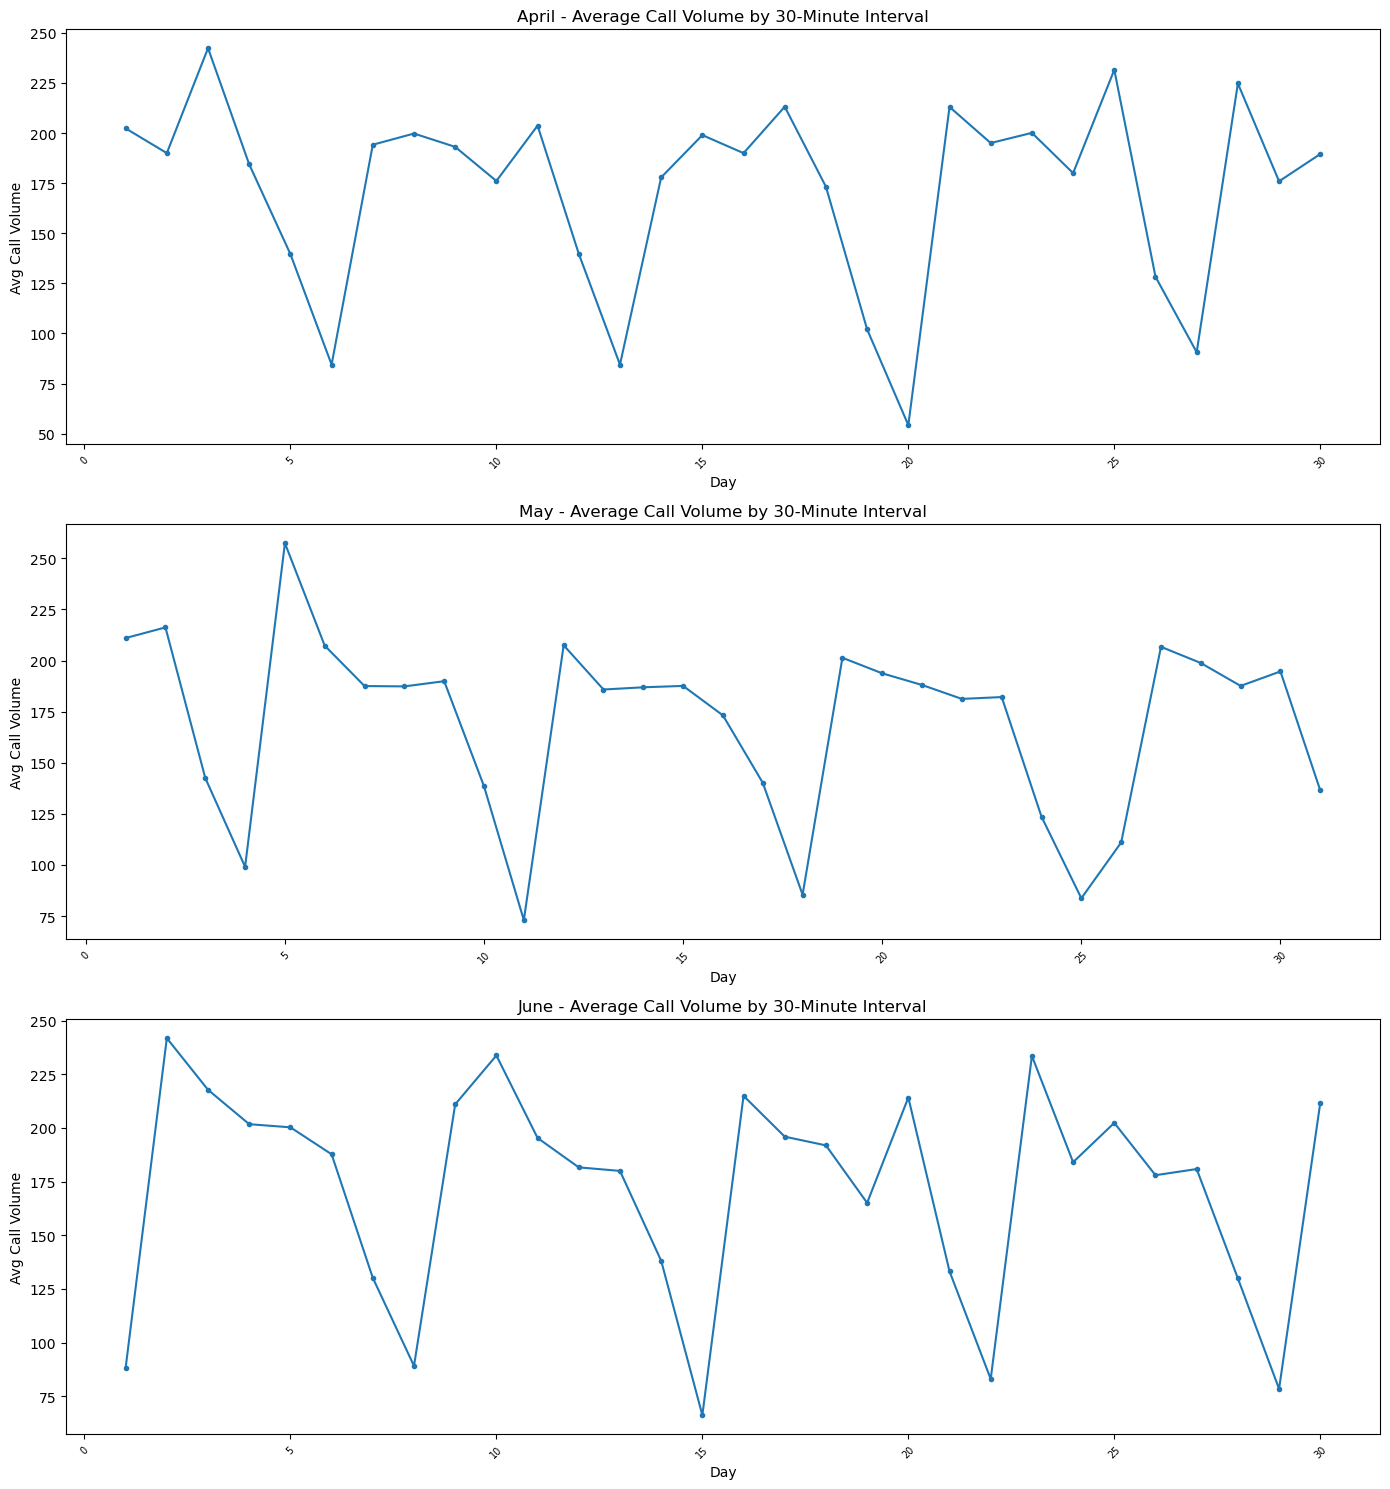

In [2]:
months = ['April', 'May', 'June']

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, month in zip(axes, months):
    df_month = df_daily[df_daily['Month'] == month]
    interval_volume = df_month.groupby('Day')['Call Volume'].mean().reset_index()

    
    ax.plot(interval_volume['Day'], interval_volume['Call Volume'], marker='o', linewidth=1.5, markersize=3)
    ax.set_title(f'{month} - Average Call Volume by 30-Minute Interval')
    ax.set_xlabel('Day')
    ax.set_ylabel('Avg Call Volume')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

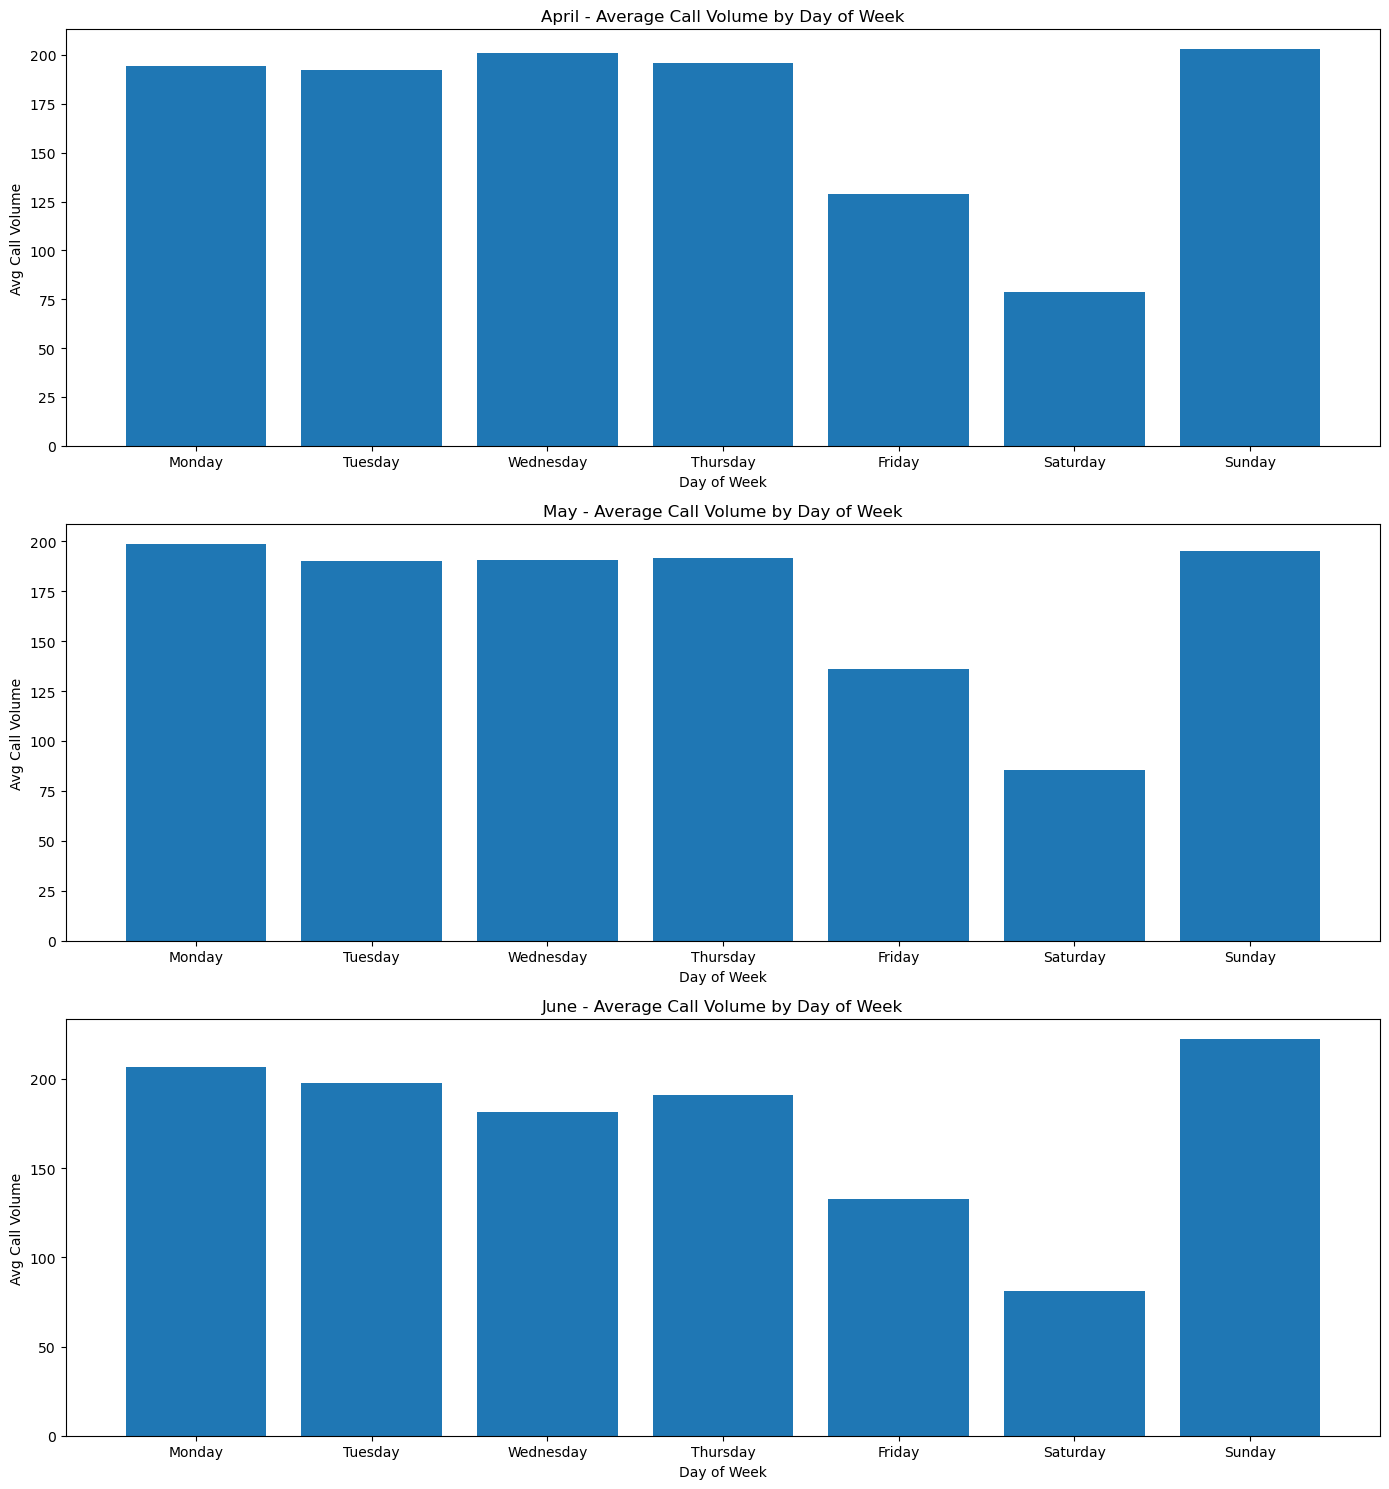

In [3]:
df_daily['Date'] = pd.to_datetime(df_daily['Month'] + ' ' + df_daily['Day'].astype(str) + ' 2024')
df_daily['DayOfWeek'] = df_daily['Date'].dt.day_name()

# Define order so it plots Mon -> Sun
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

months = ['April', 'May', 'June']

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, month in zip(axes, months):
    df_month = df_daily[df_daily['Month'] == month]
    day_volume = df_month.groupby('DayOfWeek')['Call Volume'].mean().reindex(day_order)
    
    ax.bar(day_volume.index, day_volume.values)
    ax.set_title(f'{month} - Average Call Volume by Day of Week')
    ax.set_xlabel('Day of Week')
    ax.set_ylabel('Avg Call Volume')

plt.tight_layout()
plt.show()


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [5]:
import pandas as pd
import numpy as np
from itertools import product

def load_and_clean_interval(filepath, portfolio_name):
    df = pd.read_csv(filepath)
    
    # ── 1. Standardize column names ──────────────────────────────────────────
    df.columns = df.columns.str.strip()
    
    # ── 2. Parse Service Level as float (may come in as "99.49%" or 0.9949) ──
    if df['Service Level'].dtype == object:
        df['Service Level'] = df['Service Level'].str.replace('%', '').astype(float) / 100
    
    # ── 3. Parse Abandoned Rate similarly ────────────────────────────────────
    if df['Abandoned Rate'].dtype == object:
        df['Abandoned Rate'] = df['Abandoned Rate'].str.replace('%', '').astype(float) / 100

    # ── 4. Build skeleton using ONLY valid days per month ────────────────────
    month_map = {
        'January':1,'February':2,'March':3,'April':4,
        'May':5,'June':6,'July':7,'August':8,
        'September':9,'October':10,'November':11,'December':12
    }

    all_intervals = [f"{h:02d}:{m:02d}:00" for h, m in product(range(24), [0, 30])]
    
    # Get actual (Month, Day) combos that exist in the data — avoids April 31 etc.
    valid_month_days = df[['Month', 'Day']].drop_duplicates()

    skeleton = pd.DataFrame(
        [(row.Month, row.Day, interval)
         for _, row in valid_month_days.iterrows()
         for interval in all_intervals],
        columns=['Month', 'Day', 'Interval']
    )

    df = skeleton.merge(df, on=['Month', 'Day', 'Interval'], how='left')
    
    # ── 5. Add date + time features ──────────────────────────────────────────
    df['Month_Num'] = df['Month'].map(month_map)
    df['Date']      = pd.to_datetime(
        df['Month_Num'].astype(str) + '-' + df['Day'].astype(str) + '-2024',
        format='%m-%d-%Y'
    )
    df['DayOfWeek']   = df['Date'].dt.day_name()
    df['DayOfWeek_N'] = df['Date'].dt.dayofweek        # 0=Mon, 6=Sun
    df['WeekOfMonth'] = (df['Day'] - 1) // 7 + 1
    df['IntervalIdx'] = df['Interval'].apply(
        lambda x: int(x.split(':')[0]) * 2 + int(x.split(':')[1]) // 30
    )  # 0–47
    df['Hour']       = df['Interval'].apply(lambda x: int(x.split(':')[0]))
    df['Is_Weekend'] = df['DayOfWeek_N'].isin([5, 6]).astype(int)
    df['Portfolio']  = portfolio_name

    # ── 6. Smart missing value imputation ────────────────────────────────────
    df = df.sort_values(['Month', 'Day', 'IntervalIdx']).reset_index(drop=True)

    # Overnight slots (midnight–4am): zero-fill call volume
    overnight_mask = df['IntervalIdx'].between(0, 7)
    df.loc[overnight_mask & df['Call Volume'].isna(), 'Call Volume'] = 0

    # Linear interpolation within each day, then fill edges
    for col in ['Call Volume', 'CCT', 'Abandoned Calls', 'Abandoned Rate', 'Service Level']:
        df[col] = (
            df.groupby(['Month', 'Day'])[col]
              .transform(lambda x: x.interpolate(method='linear').bfill().ffill())
        )

    # Fallback: same weekday + same interval median
    for col in ['CCT', 'Call Volume', 'Abandoned Calls', 'Abandoned Rate', 'Service Level']:
        df[col] = df.groupby(['DayOfWeek_N', 'IntervalIdx'])[col]\
                    .transform(lambda x: x.fillna(x.median()))

    # ── 7. Enforce non-negativity & valid ranges ──────────────────────────────
    for col in ['Call Volume', 'CCT', 'Abandoned Calls', 'Abandoned Rate']:
        df[col] = df[col].clip(lower=0)
    df['Abandoned Rate'] = df['Abandoned Rate'].clip(0, 1)

    # ── 8. Round volume & abandoned calls to integers ─────────────────────────
    df['Call Volume']     = df['Call Volume'].round().astype(int)
    df['Abandoned Calls'] = df['Abandoned Calls'].round().astype(int)

    return df


# ── Load all 4 portfolios ─────────────────────────────────────────────────────
portfolios = {
    'A': './data/A - Interval.csv',
    'B': './data/B - Interval.csv',
    'C': './data/C - Interval.csv',
    'D': './data/D - Interval.csv',
}

cleaned = {}
for name, path in portfolios.items():
    cleaned[name] = load_and_clean_interval(path, name)
    print(f"Portfolio {name}: {len(cleaned[name])} rows, "
          f"{cleaned[name].isna().sum().sum()} NaNs remaining")

df_all = pd.concat(cleaned.values(), ignore_index=True)
print(f"\nMaster dataframe: {df_all.shape}")


Portfolio A: 4368 rows, 292 NaNs remaining
Portfolio B: 4368 rows, 83 NaNs remaining
Portfolio C: 4368 rows, 9 NaNs remaining
Portfolio D: 4368 rows, 10 NaNs remaining

Master dataframe: (17472, 18)


=== Remaining NaNs by Portfolio & Column ===

Portfolio A:
Unnamed: 0    292
  → Affected rows:
      Month  Day  Interval  Call Volume          CCT  Abandoned Rate
8     April    1  04:00:00           18   125.000000        0.000000
9     April    1  04:30:00           32    92.000000        0.000000
55    April    2  03:30:00            0   289.165000        0.000000
57    April    2  04:30:00            1   232.500000        0.000000
101   April    3  02:30:00            0   135.625000        0.000000
102   April    3  03:00:00            0   158.250000        0.000000
103   April    3  03:30:00            0   180.875000        0.000000
148   April    4  02:00:00            0   260.100000        0.000000
149   April    4  02:30:00            0   264.200000        0.000000
150   April    4  03:00:00            0   268.300000        0.000000
201   April    5  04:30:00            2   217.000000        0.000000
202   April    5  05:00:00            2   165.000000        0.000000
242   A

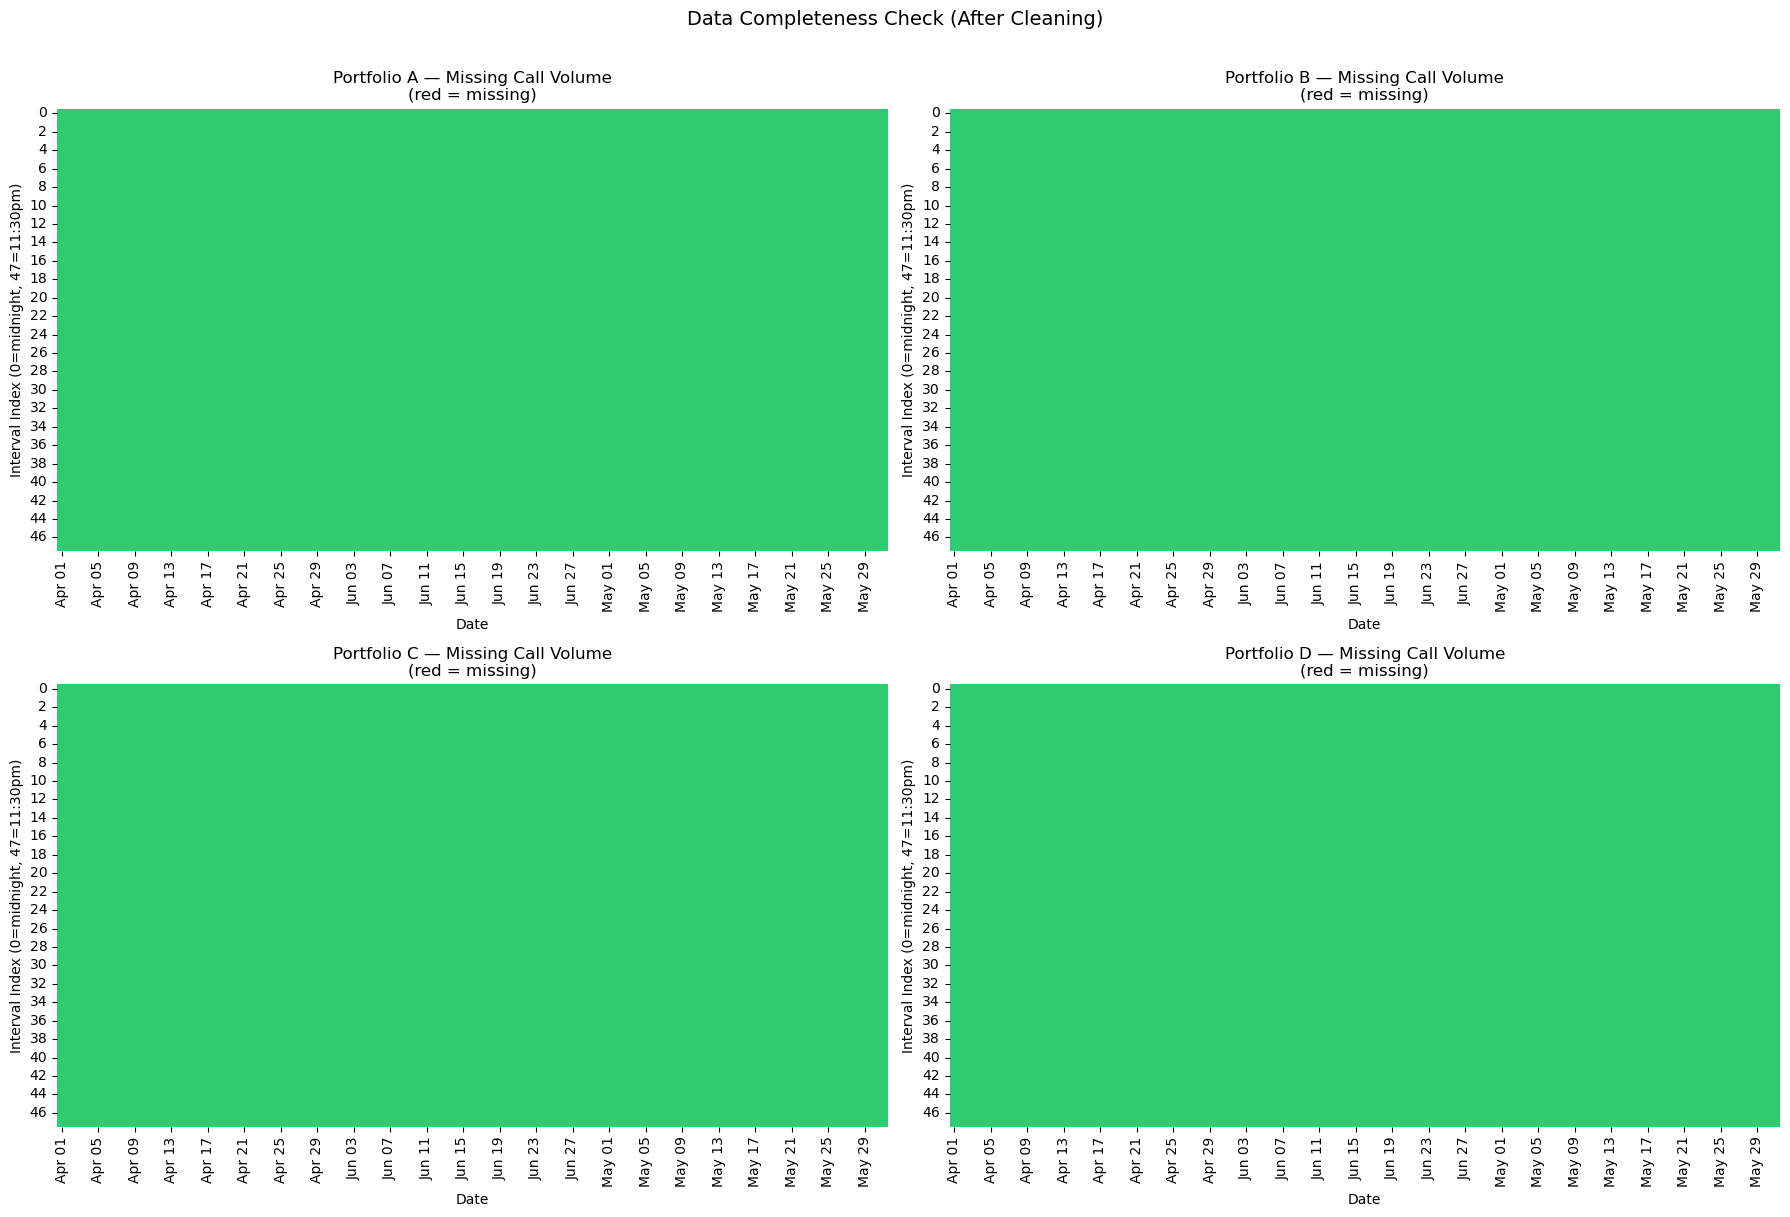

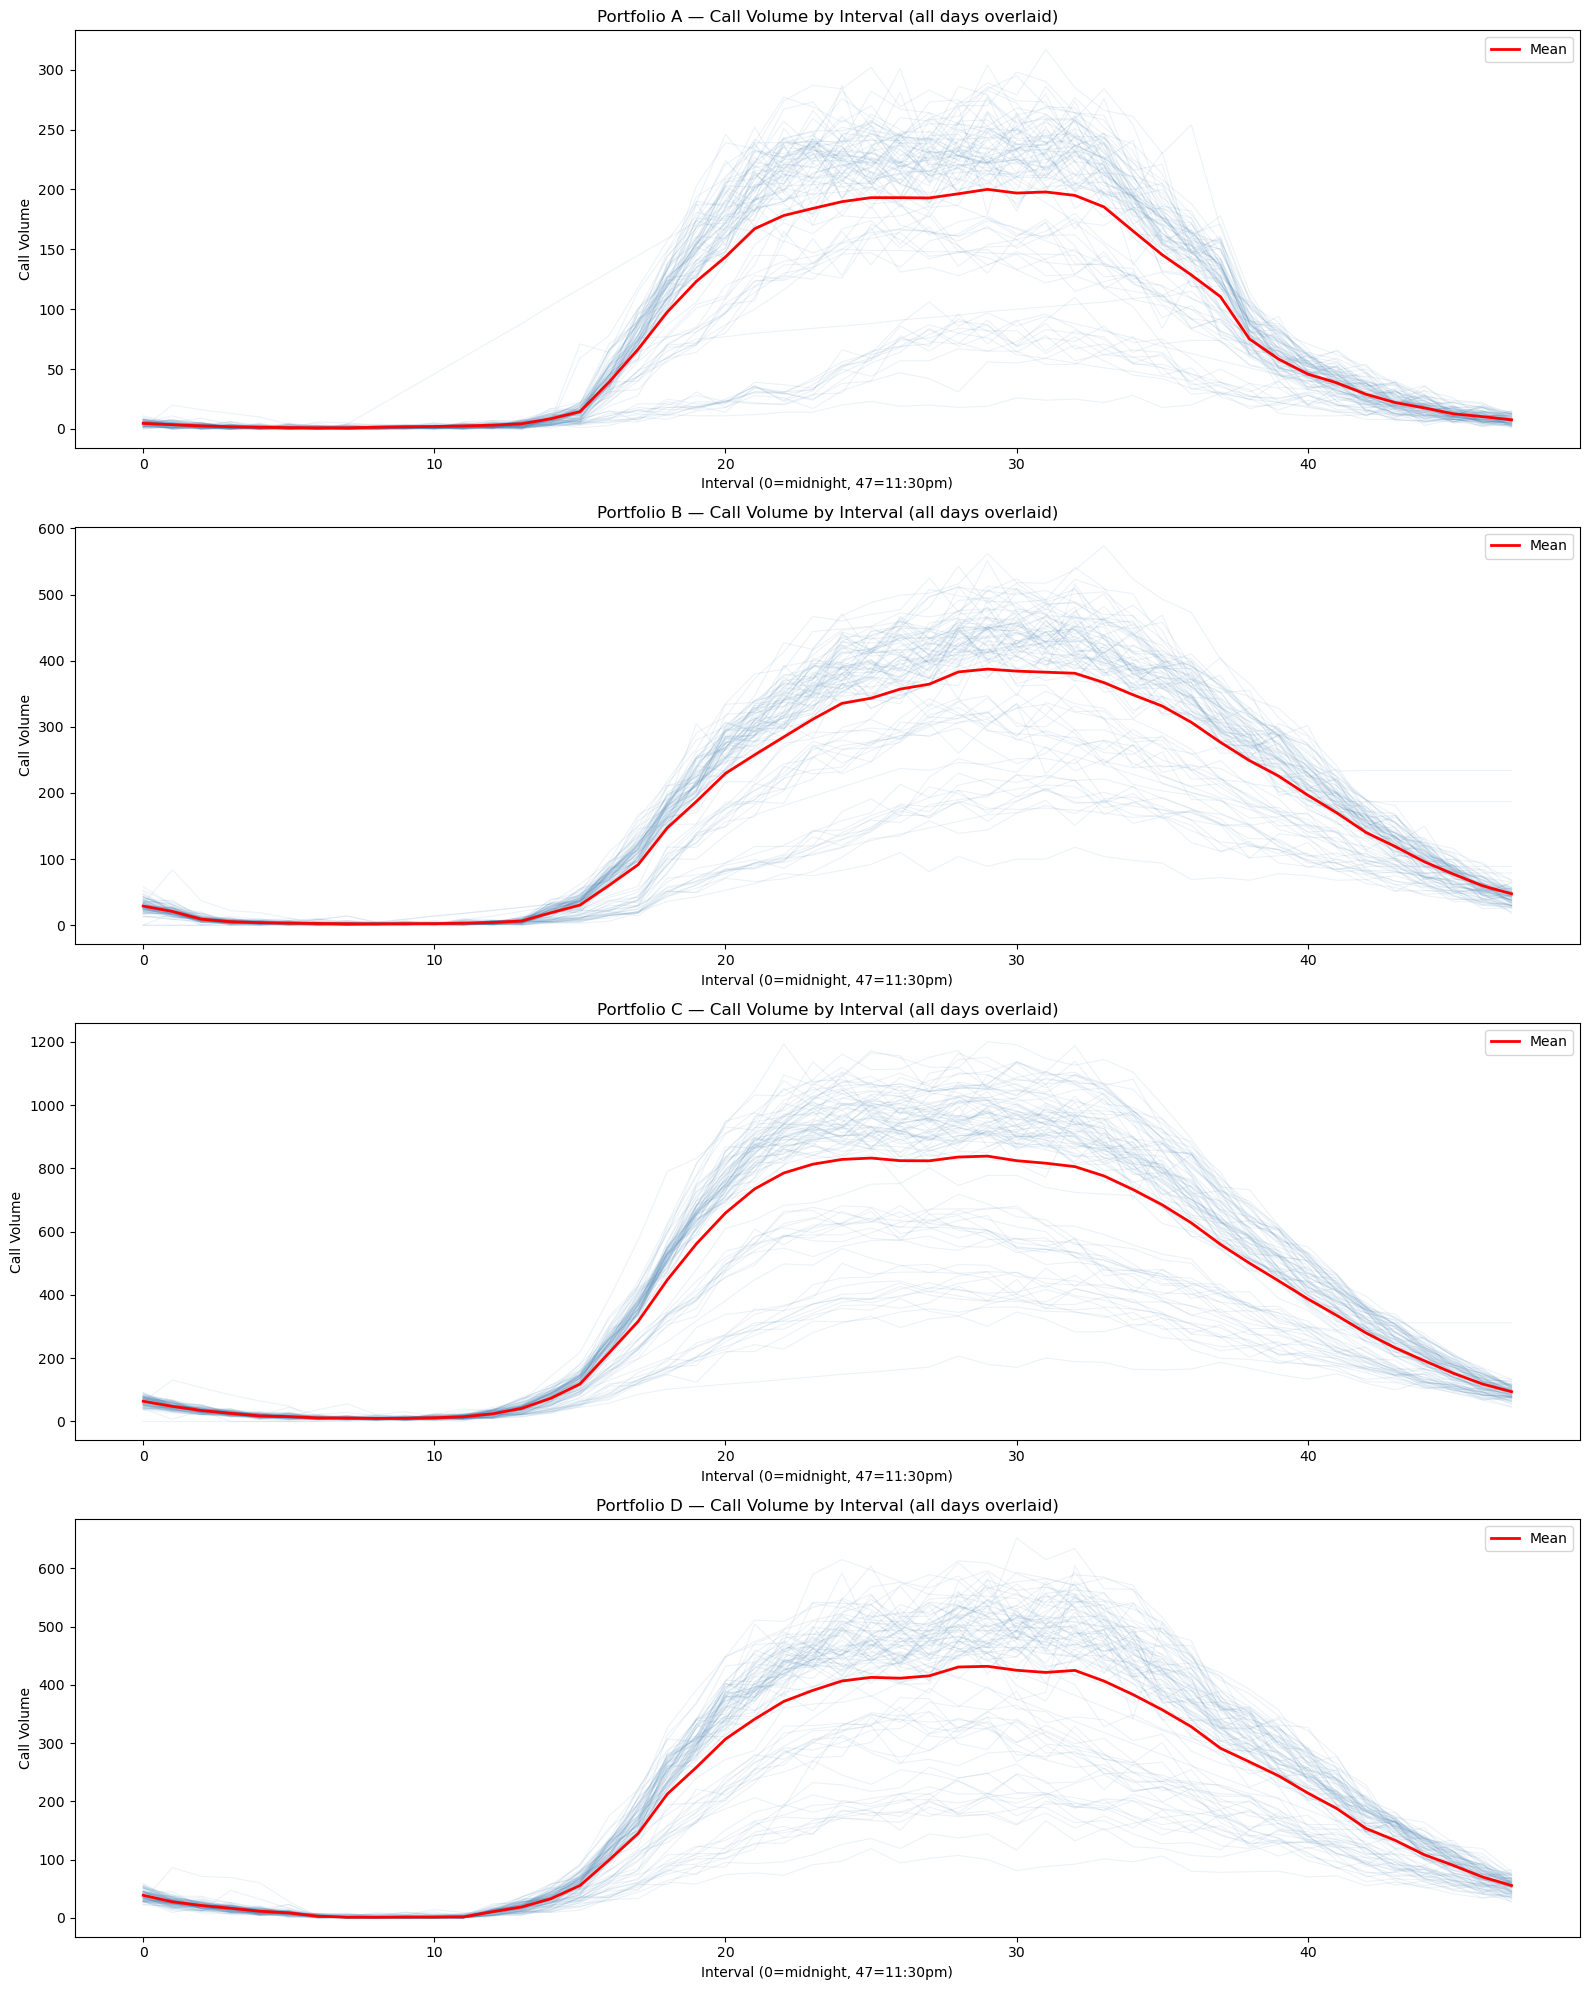


=== Sanity Check: Min/Max/Nulls per Portfolio ===

Portfolio A:


ValueError: cannot combine transform and aggregation operations

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
#doododooodod
# ── 1. Print exactly which rows/columns still have NaNs ──────────────────────
print("=== Remaining NaNs by Portfolio & Column ===\n")
for name, df in cleaned.items():
    nan_cols = df.isna().sum()
    nan_cols = nan_cols[nan_cols > 0]
    if len(nan_cols):
        print(f"Portfolio {name}:")
        print(nan_cols.to_string())
        print(f"  → Affected rows:")
        print(df[df.isna().any(axis=1)][['Month','Day','Interval','Call Volume','CCT','Abandoned Rate']].to_string())
        print()

# ── 2. Heatmap: missing data by Interval x Day (one per portfolio) ────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

target_cols = ['Call Volume', 'CCT', 'Abandoned Rate']

for i, (name, df) in enumerate(cleaned.items()):
    # Create a missingness matrix: rows = interval, cols = day-of-data
    df['DateStr'] = df['Date'].dt.strftime('%b %d')
    pivot = df.pivot_table(
        index='IntervalIdx', 
        columns='DateStr', 
        values='Call Volume',
        aggfunc=lambda x: x.isna().sum()
    )
    
    sns.heatmap(
        pivot, ax=axes[i],
        cmap=['#2ecc71', '#e74c3c'],   # green = present, red = missing
        cbar=False, linewidths=0,
        xticklabels=4                  # show every 4th date label
    )
    axes[i].set_title(f'Portfolio {name} — Missing Call Volume\n(red = missing)', fontsize=12)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Interval Index (0=midnight, 47=11:30pm)')

plt.suptitle('Data Completeness Check (After Cleaning)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── 3. Line plot: call volume over all intervals to spot weird flat regions ───
fig, axes = plt.subplots(4, 1, figsize=(16, 20))

for i, (name, df) in enumerate(cleaned.items()):
    # Plot each day as a faint line, overlay the mean
    for (month, day), grp in df.groupby(['Month', 'Day']):
        axes[i].plot(grp['IntervalIdx'], grp['Call Volume'], 
                     alpha=0.1, color='steelblue', linewidth=0.8)
    
    mean_line = df.groupby('IntervalIdx')['Call Volume'].mean()
    axes[i].plot(mean_line.index, mean_line.values, 
                 color='red', linewidth=2, label='Mean')
    
    axes[i].set_title(f'Portfolio {name} — Call Volume by Interval (all days overlaid)')
    axes[i].set_xlabel('Interval (0=midnight, 47=11:30pm)')
    axes[i].set_ylabel('Call Volume')
    axes[i].legend()

plt.tight_layout()
plt.show()

# ── 4. Quick sanity check table ───────────────────────────────────────────────
print("\n=== Sanity Check: Min/Max/Nulls per Portfolio ===\n")
for name, df in cleaned.items():
    print(f"Portfolio {name}:")
    print(df[['Call Volume','CCT','Abandoned Calls','Abandoned Rate']].agg(['min','max','mean','isnull']).T)
    print()
    for name, df in cleaned.items():
        nan_cols = df.isna().sum()
        nan_cols = nan_cols[nan_cols > 0]
    if len(nan_cols):
        print(f"Portfolio {name}:")
        print(nan_cols.to_string())
        print(f"  → Affected rows:")
        print(df[df.isna().any(axis=1)][['Month','Day','Interval','Call Volume','CCT','Abandoned Rate']].to_string())
        print()


In [ ]:
# ── Rebuild cleaned dict if kernel was restarted ─────────────────────────────
import pandas as pd
import numpy as np
from itertools import product

def load_and_clean_interval(filepath, portfolio_name):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()

    if df['Service Level'].dtype == object:
        df['Service Level'] = df['Service Level'].str.replace('%', '').astype(float) / 100
    if df['Abandoned Rate'].dtype == object:
        df['Abandoned Rate'] = df['Abandoned Rate'].str.replace('%', '').astype(float) / 100

    month_map = {
        'January':1,'February':2,'March':3,'April':4,
        'May':5,'June':6,'July':7,'August':8,
        'September':9,'October':10,'November':11,'December':12
    }

    all_intervals = [f"{h:02d}:{m:02d}:00" for h, m in product(range(24), [0, 30])]
    valid_month_days = df[['Month', 'Day']].drop_duplicates()
    skeleton = pd.DataFrame(
        [(row.Month, row.Day, interval)
         for _, row in valid_month_days.iterrows()
         for interval in all_intervals],
        columns=['Month', 'Day', 'Interval']
    )
    df = skeleton.merge(df, on=['Month', 'Day', 'Interval'], how='left')

    df['Month_Num']   = df['Month'].map(month_map)
    df['Date']        = pd.to_datetime(
        df['Month_Num'].astype(str) + '-' + df['Day'].astype(str) + '-2024',
        format='%m-%d-%Y'
    )
    df['DayOfWeek']   = df['Date'].dt.day_name()
    df['DayOfWeek_N'] = df['Date'].dt.dayofweek
    df['WeekOfMonth'] = (df['Day'] - 1) // 7 + 1
    df['IntervalIdx'] = df['Interval'].apply(
        lambda x: int(x.split(':')[0]) * 2 + int(x.split(':')[1]) // 30
    )
    df['Hour']        = df['Interval'].apply(lambda x: int(x.split(':')[0]))
    df['Is_Weekend']  = df['DayOfWeek_N'].isin([5, 6]).astype(int)
    df['Portfolio']   = portfolio_name

    df = df.sort_values(['Month', 'Day', 'IntervalIdx']).reset_index(drop=True)

    overnight_mask = df['IntervalIdx'].between(0, 7)
    df.loc[overnight_mask & df['Call Volume'].isna(), 'Call Volume'] = 0

    for col in ['Call Volume', 'CCT', 'Abandoned Calls', 'Abandoned Rate', 'Service Level']:
        df[col] = (
            df.groupby(['Month', 'Day'])[col]
              .transform(lambda x: x.interpolate(method='linear').bfill().ffill())
        )
    for col in ['CCT', 'Call Volume', 'Abandoned Calls', 'Abandoned Rate', 'Service Level']:
        df[col] = df.groupby(['DayOfWeek_N', 'IntervalIdx'])[col]\
                    .transform(lambda x: x.fillna(x.median()))

    for col in ['Call Volume', 'CCT', 'Abandoned Calls', 'Abandoned Rate']:
        df[col] = df[col].clip(lower=0)
    df['Abandoned Rate'] = df['Abandoned Rate'].clip(0, 1)
    df['Call Volume']     = df['Call Volume'].round().astype(int)
    df['Abandoned Calls'] = df['Abandoned Calls'].round().astype(int)

    return df

portfolios = {
    'A': './data/A - Interval.csv',
    'B': './data/B - Interval.csv',
    'C': './data/C - Interval.csv',
    'D': './data/D - Interval.csv',
}

cleaned = {}
for name, path in portfolios.items():
    cleaned[name] = load_and_clean_interval(path, name)
    print(f"Portfolio {name}: {len(cleaned[name])} rows, "
          f"{cleaned[name].isna().sum().sum()} NaNs remaining")

print("\ncleaned dict ready — proceeding to Stage 1...\n")

Portfolio A: 4368 rows, 292 NaNs remaining
Portfolio B: 4368 rows, 83 NaNs remaining
Portfolio C: 4368 rows, 9 NaNs remaining
Portfolio D: 4368 rows, 10 NaNs remaining

cleaned dict ready — proceeding to Stage 1...



=== Stage 1: Training XGBoost daily models ===



  [A] CV   | MAE= 354.893 | MAPE=  10.2%
  [A] CCT  | MAE=   8.094 | MAPE=   2.6%
  [A] ABD  | MAE=   0.007 | MAPE= 125.8%
  [B] CV   | MAE= 771.026 | MAPE=  10.0%
  [B] CCT  | MAE=   6.549 | MAPE=   2.0%
  [B] ABD  | MAE=   0.008 | MAPE= 127.3%
  [C] CV   | MAE=1441.047 | MAPE=   9.5%
  [C] CCT  | MAE=   6.691 | MAPE=   2.0%
  [C] ABD  | MAE=   0.006 | MAPE= 159.9%
  [D] CV   | MAE= 910.401 | MAPE=  11.5%
  [D] CCT  | MAE=   5.753 | MAPE=   1.9%
  [D] ABD  | MAE=   0.010 | MAPE= 106.3%

=== Cross-validation summary ===
Portfolio Target      CV_MAE   CV_MAPE%
        A     CV  354.892815  10.194142
        A    CCT    8.094023   2.580619
        A    ABD    0.006949 125.828281
        B     CV  771.025913   9.969402
        B    CCT    6.549050   2.018635
        B    ABD    0.008098 127.326735
        C     CV 1441.046524   9.463714
        C    CCT    6.691358   2.024394
        C    ABD    0.006285 159.949995
        D     CV  910.400549  11.458829
        D    CCT    5.753050   1.8

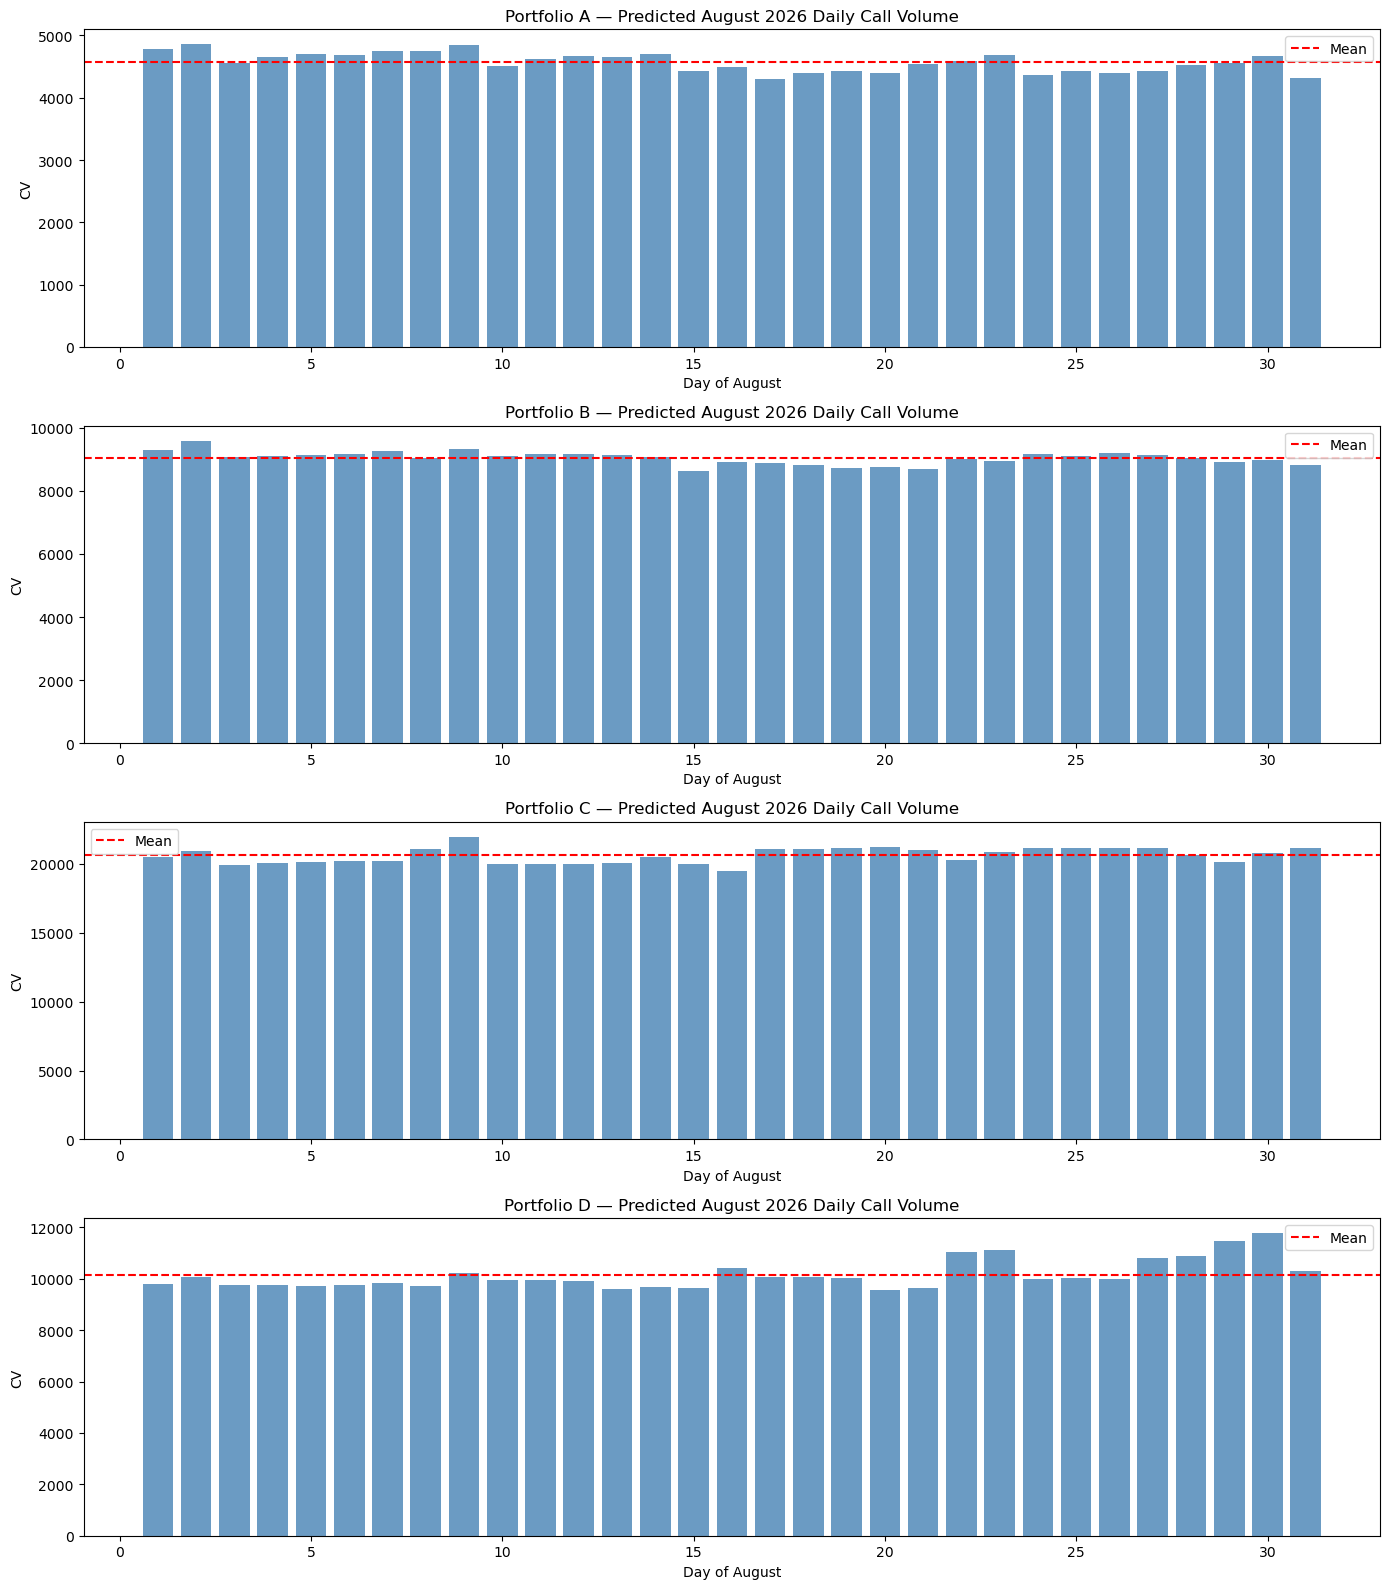

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import holidays
import warnings
warnings.filterwarnings('ignore')

# ── Helper: US holidays ───────────────────────────────────────────────────────
us_holidays = holidays.US(years=[2024, 2025, 2026])

def add_daily_features(df_daily):
    """
    Build the feature matrix from a daily-aggregated dataframe.
    Expects columns: Date, DayOfWeek_N, Day, Month_Num, WeekOfMonth
    """
    df = df_daily.copy().sort_values('Date').reset_index(drop=True)

    # ── Calendar features ─────────────────────────────────────────────────────
    df['is_weekend']     = df['DayOfWeek_N'].isin([5, 6]).astype(int)
    df['is_monday']      = (df['DayOfWeek_N'] == 0).astype(int)  # Mondays spike
    df['is_holiday']     = df['Date'].isin(us_holidays).astype(int)
    df['day_of_year']    = df['Date'].dt.dayofyear
    df['days_in_month']  = df['Date'].dt.days_in_month
    df['week_of_year']   = df['Date'].dt.isocalendar().week.astype(int)

    # ── Lag features (same weekday previous weeks) ────────────────────────────
    for col in ['CV', 'CCT', 'ABD']:
        # lag 7 = same weekday 1 week ago
        df[f'{col}_lag7']  = df[col].shift(7)
        # lag 14 = same weekday 2 weeks ago
        df[f'{col}_lag14'] = df[col].shift(14)
        # rolling 4-week mean (of prior same-weekday values)
        df[f'{col}_roll4'] = (
            df[col].shift(7).rolling(4, min_periods=1).mean()
        )

    return df


def aggregate_to_daily(cleaned_dict):
    """
    Collapse interval-level cleaned data to one row per (Portfolio, Date).
    CV  = sum of Call Volume
    CCT = weighted mean (weighted by Call Volume)
    ABD = Abandoned Calls / Call Volume
    """
    daily_frames = []
    for name, df in cleaned_dict.items():
        g = df.groupby(['Portfolio', 'Date', 'DayOfWeek_N',
                         'Day', 'Month_Num', 'WeekOfMonth', 'Is_Weekend'])

        agg = g.apply(lambda x: pd.Series({
            'CV':  x['Call Volume'].sum(),
            'CCT': np.average(x['CCT'], weights=x['Call Volume'].clip(1)),
            'ABD': x['Abandoned Calls'].sum() / x['Call Volume'].sum().clip(1),
        })).reset_index()

        daily_frames.append(agg)

    return pd.concat(daily_frames, ignore_index=True)


def build_feature_cols():
    return [
        'DayOfWeek_N', 'WeekOfMonth', 'Month_Num', 'Is_Weekend',
        'is_monday', 'is_holiday', 'day_of_year', 'week_of_year',
        'CV_lag7',  'CV_lag14',  'CV_roll4',
        'CCT_lag7', 'CCT_lag14', 'CCT_roll4',
        'ABD_lag7', 'ABD_lag14', 'ABD_roll4',
    ]


def train_stage1(cleaned_dict, verbose=True):
    """
    Train one XGBRegressor per (portfolio, target).
    Returns: models dict, daily dataframe with features, eval metrics.
    """
    # Step 1 — daily aggregation
    df_daily = aggregate_to_daily(cleaned_dict)
    df_daily = df_daily.sort_values(['Portfolio', 'Date']).reset_index(drop=True)

    # Step 2 — add features per portfolio (lags must be computed within portfolio)
    enriched = []
    for portfolio, grp in df_daily.groupby('Portfolio'):
        enriched.append(add_daily_features(grp))
    df_daily = pd.concat(enriched, ignore_index=True)

    feature_cols = build_feature_cols()
    targets      = ['CV', 'CCT', 'ABD']

    models  = {}   # models[(portfolio, target)] = fitted XGBRegressor
    metrics = []   # list of dicts for eval summary

    xgb_params = dict(
        n_estimators     = 300,
        max_depth        = 4,         # shallow — only 90 days of data
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 3,         # prevents overfitting on small data
        reg_lambda       = 2.0,       # L2 regularisation
        random_state     = 42,
        n_jobs           = -1,
    )

    for portfolio in sorted(df_daily['Portfolio'].unique()):
        pf_df = df_daily[df_daily['Portfolio'] == portfolio].copy()
        # Drop rows where lag features are NaN (first 14 days)
        pf_df = pf_df.dropna(subset=feature_cols).reset_index(drop=True)

        for target in targets:
            X = pf_df[feature_cols]
            y = pf_df[target]

            # ── Time-series cross-validation (no leakage) ─────────────────────
            tscv    = TimeSeriesSplit(n_splits=3)
            cv_maes = []
            cv_mapes = []

            for train_idx, val_idx in tscv.split(X):
                X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

                m = XGBRegressor(**xgb_params)
                m.fit(X_tr, y_tr,
                      eval_set=[(X_val, y_val)],
                      verbose=False)

                preds = m.predict(X_val).clip(0)
                if target == 'ABD':
                    preds = preds.clip(0, 1)

                cv_maes.append(mean_absolute_error(y_val, preds))
                # MAPE: skip intervals where true = 0
                mask = y_val > 0
                if mask.sum() > 0:
                    cv_mapes.append(
                        mean_absolute_percentage_error(y_val[mask], preds[mask]) * 100
                    )

            # nee to learn how to understand this
            final_model = XGBRegressor(**xgb_params)
            final_model.fit(X, y, verbose=False)
            models[(portfolio, target)] = final_model

            metrics.append({
                'Portfolio': portfolio,
                'Target':    target,
                'CV_MAE':    np.mean(cv_maes),
                'CV_MAPE%':  np.mean(cv_mapes) if cv_mapes else np.nan,
            })

            if verbose:
                print(f"  [{portfolio}] {target:4s} | "
                      f"MAE={np.mean(cv_maes):8.3f} | "
                      f"MAPE={np.mean(cv_mapes) if cv_mapes else float('nan'):6.1f}%")

    metrics_df = pd.DataFrame(metrics)
    return models, df_daily, metrics_df


def predict_august(models, df_daily, year=2026):
    """
    Generate daily predictions for every day in August for each portfolio.
    Uses the last 14 days of known data as the lag seed.
    """
    feature_cols = build_feature_cols()
    targets      = ['CV', 'CCT', 'ABD']
    august_dates = pd.date_range(f'{year}-08-01', f'{year}-08-31', freq='D')

    all_preds = []

    for portfolio in sorted(df_daily['Portfolio'].unique()):
        pf_hist = (df_daily[df_daily['Portfolio'] == portfolio]
                   .sort_values('Date').copy())

        # Rolling buffer — we'll append predictions as we go (autoregressive)
        buffer = pf_hist[['Date', 'CV', 'CCT', 'ABD']].copy()

        for date in august_dates:
            row = {
                'Date':        date,
                'DayOfWeek_N': date.dayofweek,
                'WeekOfMonth': (date.day - 1) // 7 + 1,
                'Month_Num':   date.month,
                'Is_Weekend':  int(date.dayofweek in [5, 6]),
                'is_monday':   int(date.dayofweek == 0),
                'is_holiday':  int(date in us_holidays),
                'day_of_year': date.dayofyear,
                'week_of_year': date.isocalendar()[1],
            }

            # Build lag features from buffer
            for tgt in targets:
                lag7_date  = date - pd.Timedelta(days=7)
                lag14_date = date - pd.Timedelta(days=14)

                lag7_val  = buffer.loc[buffer['Date'] == lag7_date,  tgt]
                lag14_val = buffer.loc[buffer['Date'] == lag14_date, tgt]

                row[f'{tgt}_lag7']  = lag7_val.values[0]  if len(lag7_val)  else np.nan
                row[f'{tgt}_lag14'] = lag14_val.values[0] if len(lag14_val) else np.nan

                # rolling 4-week mean of lag-7 through lag-28
                roll_vals = []
                for w in range(1, 5):
                    d = date - pd.Timedelta(days=7*w)
                    v = buffer.loc[buffer['Date'] == d, tgt]
                    if len(v):
                        roll_vals.append(v.values[0])
                row[f'{tgt}_roll4'] = np.mean(roll_vals) if roll_vals else np.nan

            X_row = pd.DataFrame([row])[feature_cols]

            pred_row = {'Portfolio': portfolio, 'Date': date}
            for tgt in targets:
                model = models[(portfolio, tgt)]
                pred  = float(model.predict(X_row)[0])
                pred  = max(0, pred)
                if tgt == 'ABD':
                    pred = min(pred, 1.0)
                pred_row[tgt] = pred

            all_preds.append(pred_row)

            # Append prediction to buffer so future lags can use it
            buffer = pd.concat([
                buffer,
                pd.DataFrame([{'Date': date,
                               'CV':  pred_row['CV'],
                               'CCT': pred_row['CCT'],
                               'ABD': pred_row['ABD']}])
            ], ignore_index=True)

    return pd.DataFrame(all_preds)


# ══════════════════════════════════════════════════════════════════════════════
# RUN IT
# ══════════════════════════════════════════════════════════════════════════════

print("=== Stage 1: Training XGBoost daily models ===\n")
models, df_daily_features, metrics_df = train_stage1(cleaned)

print("\n=== Cross-validation summary ===")
print(metrics_df.to_string(index=False))

print("\n=== Predicting August 2026 ===")
august_preds = predict_august(models, df_daily_features, year=2026)
print(august_preds)

# ── Quick sanity plot ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
for i, portfolio in enumerate(['A', 'B', 'C', 'D']):
    pf = august_preds[august_preds['Portfolio'] == portfolio]
    axes[i].bar(pf['Date'].dt.day, pf['CV'], color='steelblue', alpha=0.8)
    axes[i].set_title(f'Portfolio {portfolio} — Predicted August 2026 Daily Call Volume')
    axes[i].set_xlabel('Day of August')
    axes[i].set_ylabel('CV')
    axes[i].axhline(pf['CV'].mean(), color='red', linestyle='--', label='Mean')
    axes[i].legend()

plt.tight_layout()
plt.show()

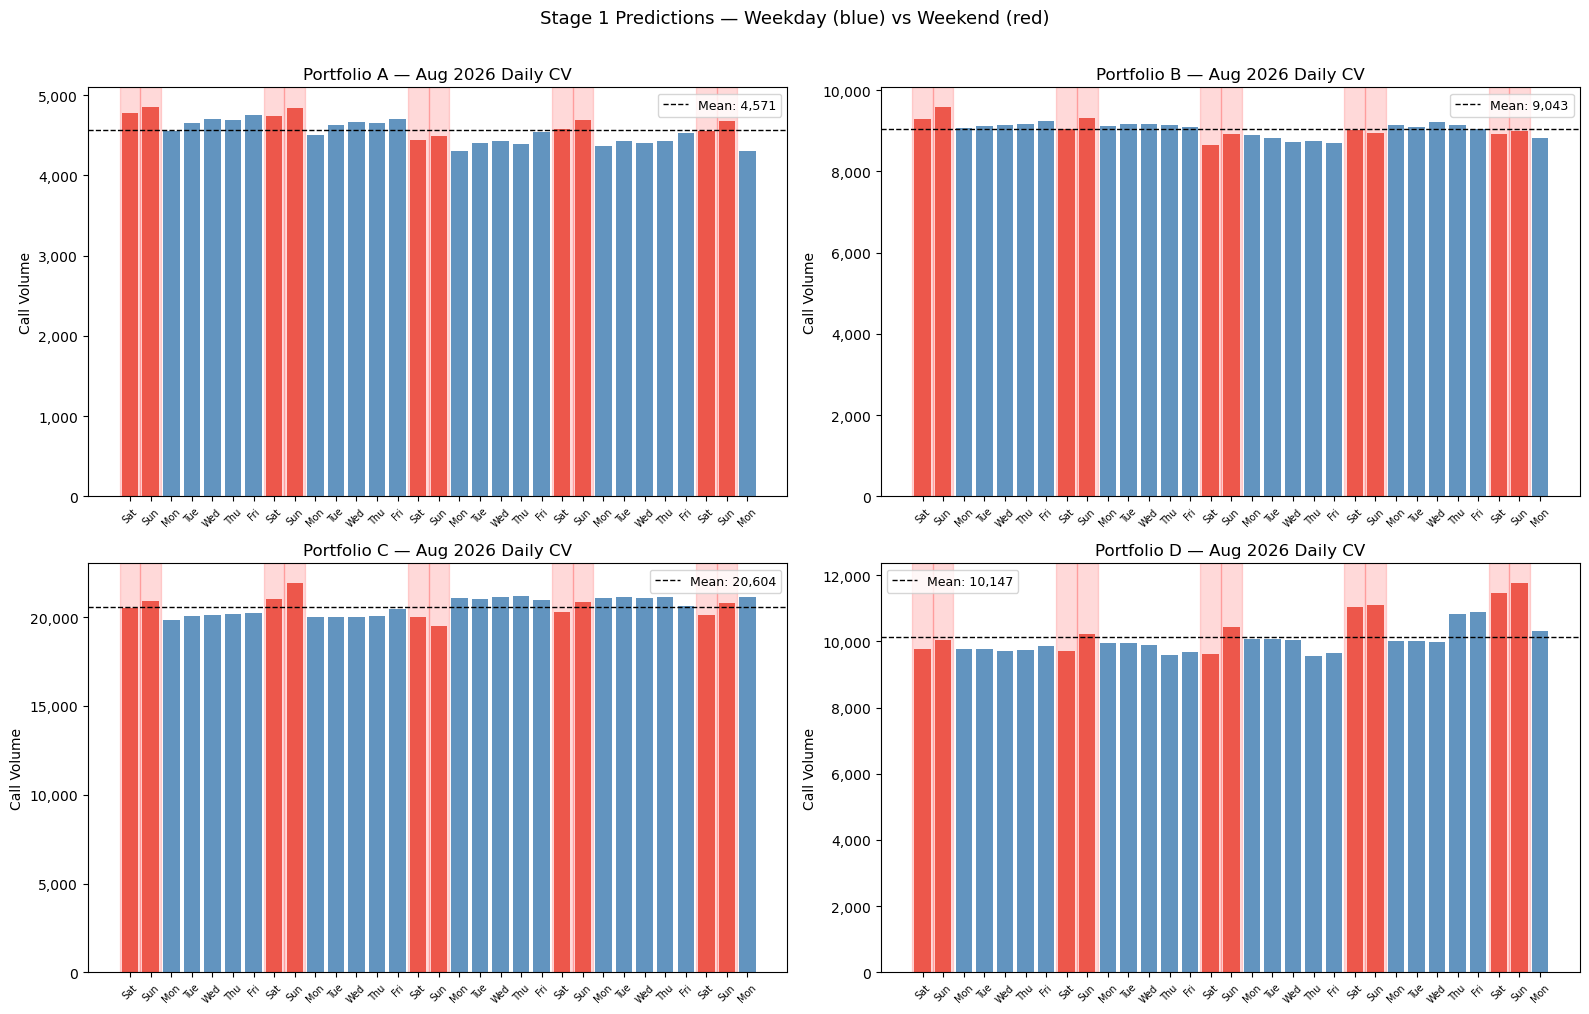

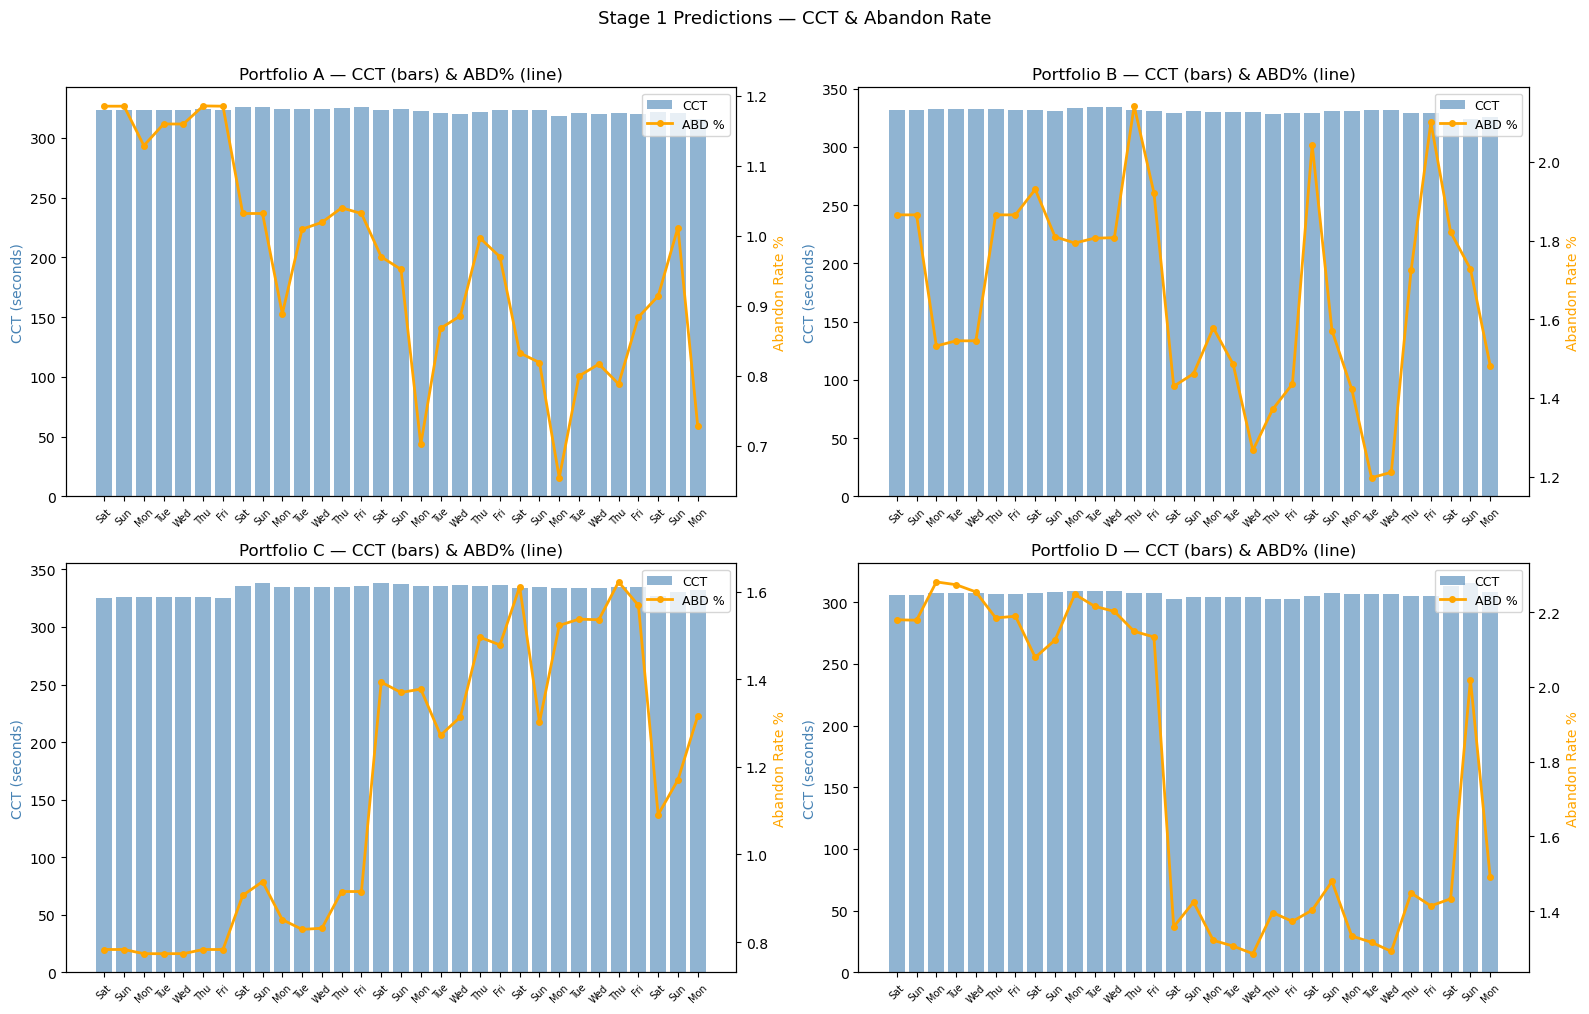


=== August 2026 Prediction Summary ===

Portfolio A:
  CV  — mean:      4,571  min:      4,301  max:      4,856
  CCT — mean:      322.7  min:      316.3  max:      326.1
  ABD — mean:     0.0096  min:     0.0065  max:     0.0119

Portfolio B:
  CV  — mean:      9,043  min:      8,643  max:      9,587
  CCT — mean:      330.3  min:      321.7  max:      334.4
  ABD — mean:     0.0167  min:     0.0120  max:     0.0214

Portfolio C:
  CV  — mean:     20,604  min:     19,494  max:     21,939
  CCT — mean:      332.7  min:      325.2  max:      338.4
  ABD — mean:     0.0115  min:     0.0077  max:     0.0162

Portfolio D:
  CV  — mean:     10,147  min:      9,550  max:     11,773
  CCT — mean:      306.9  min:      302.4  max:      315.8
  ABD — mean:     0.0177  min:     0.0129  max:     0.0228


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

for i, portfolio in enumerate(['A', 'B', 'C', 'D']):
    pf = august_preds[august_preds['Portfolio'] == portfolio].copy()
    pf['DayOfWeek_N'] = pd.to_datetime(pf['Date']).dt.dayofweek
    pf['CV'] = pf['CV'].round().astype(int)

    # Color bars by weekday vs weekend
    colors = ['#e74c3c' if d >= 5 else 'steelblue' 
              for d in pf['DayOfWeek_N']]

    axes[i].bar(pf['Date'].dt.day, pf['CV'], color=colors, alpha=0.85)
    axes[i].axhline(pf['CV'].mean(), color='black', linestyle='--', 
                    linewidth=1, label=f"Mean: {pf['CV'].mean():,.0f}")

    # Annotate day names on x axis
    axes[i].set_xticks(pf['Date'].dt.day)
    axes[i].set_xticklabels(
        [day_names[d] for d in pf['DayOfWeek_N']], 
        rotation=45, fontsize=7
    )
    axes[i].set_title(f'Portfolio {portfolio} — Aug 2026 Daily CV')
    axes[i].set_ylabel('Call Volume')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[i].legend(fontsize=9)

    # Add weekend shading
    for _, row in pf[pf['DayOfWeek_N'] >= 5].iterrows():
        axes[i].axvspan(row['Date'].day - 0.5, row['Date'].day + 0.5, 
                        alpha=0.15, color='red')

# Fix august_preds CV to int globally
august_preds['CV'] = august_preds['CV'].round().astype(int)

plt.suptitle('Stage 1 Predictions — Weekday (blue) vs Weekend (red)', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Also check CCT and ABD patterns ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, portfolio in enumerate(['A', 'B', 'C', 'D']):
    pf = august_preds[august_preds['Portfolio'] == portfolio].copy()
    pf['DayOfWeek_N'] = pd.to_datetime(pf['Date']).dt.dayofweek

    ax2 = axes[i].twinx()
    axes[i].bar(pf['Date'].dt.day, pf['CCT'], color='steelblue', 
                alpha=0.6, label='CCT')
    ax2.plot(pf['Date'].dt.day, pf['ABD'] * 100, color='orange', 
             linewidth=2, marker='o', markersize=4, label='ABD %')

    axes[i].set_title(f'Portfolio {portfolio} — CCT (bars) & ABD% (line)')
    axes[i].set_ylabel('CCT (seconds)', color='steelblue')
    ax2.set_ylabel('Abandon Rate %', color='orange')
    axes[i].set_xticks(pf['Date'].dt.day)
    axes[i].set_xticklabels(
        [day_names[d] for d in pf['DayOfWeek_N']], 
        rotation=45, fontsize=7
    )

    lines1, labels1 = axes[i].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[i].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.suptitle('Stage 1 Predictions — CCT & Abandon Rate', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n=== August 2026 Prediction Summary ===")
for portfolio in ['A','B','C','D']:
    pf = august_preds[august_preds['Portfolio'] == portfolio]
    print(f"\nPortfolio {portfolio}:")
    print(f"  CV  — mean: {pf['CV'].mean():>10,.0f}  "
          f"min: {pf['CV'].min():>10,.0f}  max: {pf['CV'].max():>10,.0f}")
    print(f"  CCT — mean: {pf['CCT'].mean():>10.1f}  "
          f"min: {pf['CCT'].min():>10.1f}  max: {pf['CCT'].max():>10.1f}")
    print(f"  ABD — mean: {pf['ABD'].mean():>10.4f}  "
          f"min: {pf['ABD'].min():>10.4f}  max: {pf['ABD'].max():>10.4f}")

Building intraday profiles from historical data...
Profile shape: (1344, 10) (4 portfolios × 7 days × 48 intervals)

Applying profiles to August 2026 daily predictions...
Output shape: (5952, 12)
Expected:     5952 rows (31 days × 48 intervals × 4 portfolios)
  Portfolio       Date   Month  Day DayOfWeek  DayOfWeek_N  Interval  \
0         A 2026-08-01  August    1  Saturday            5  00:00:00   
1         A 2026-08-01  August    1  Saturday            5  00:30:00   
2         A 2026-08-01  August    1  Saturday            5  01:00:00   
3         A 2026-08-01  August    1  Saturday            5  01:30:00   
4         A 2026-08-01  August    1  Saturday            5  02:00:00   
5         A 2026-08-01  August    1  Saturday            5  02:30:00   
6         A 2026-08-01  August    1  Saturday            5  03:00:00   
7         A 2026-08-01  August    1  Saturday            5  03:30:00   
8         A 2026-08-01  August    1  Saturday            5  04:00:00   
9         A 2026-08-

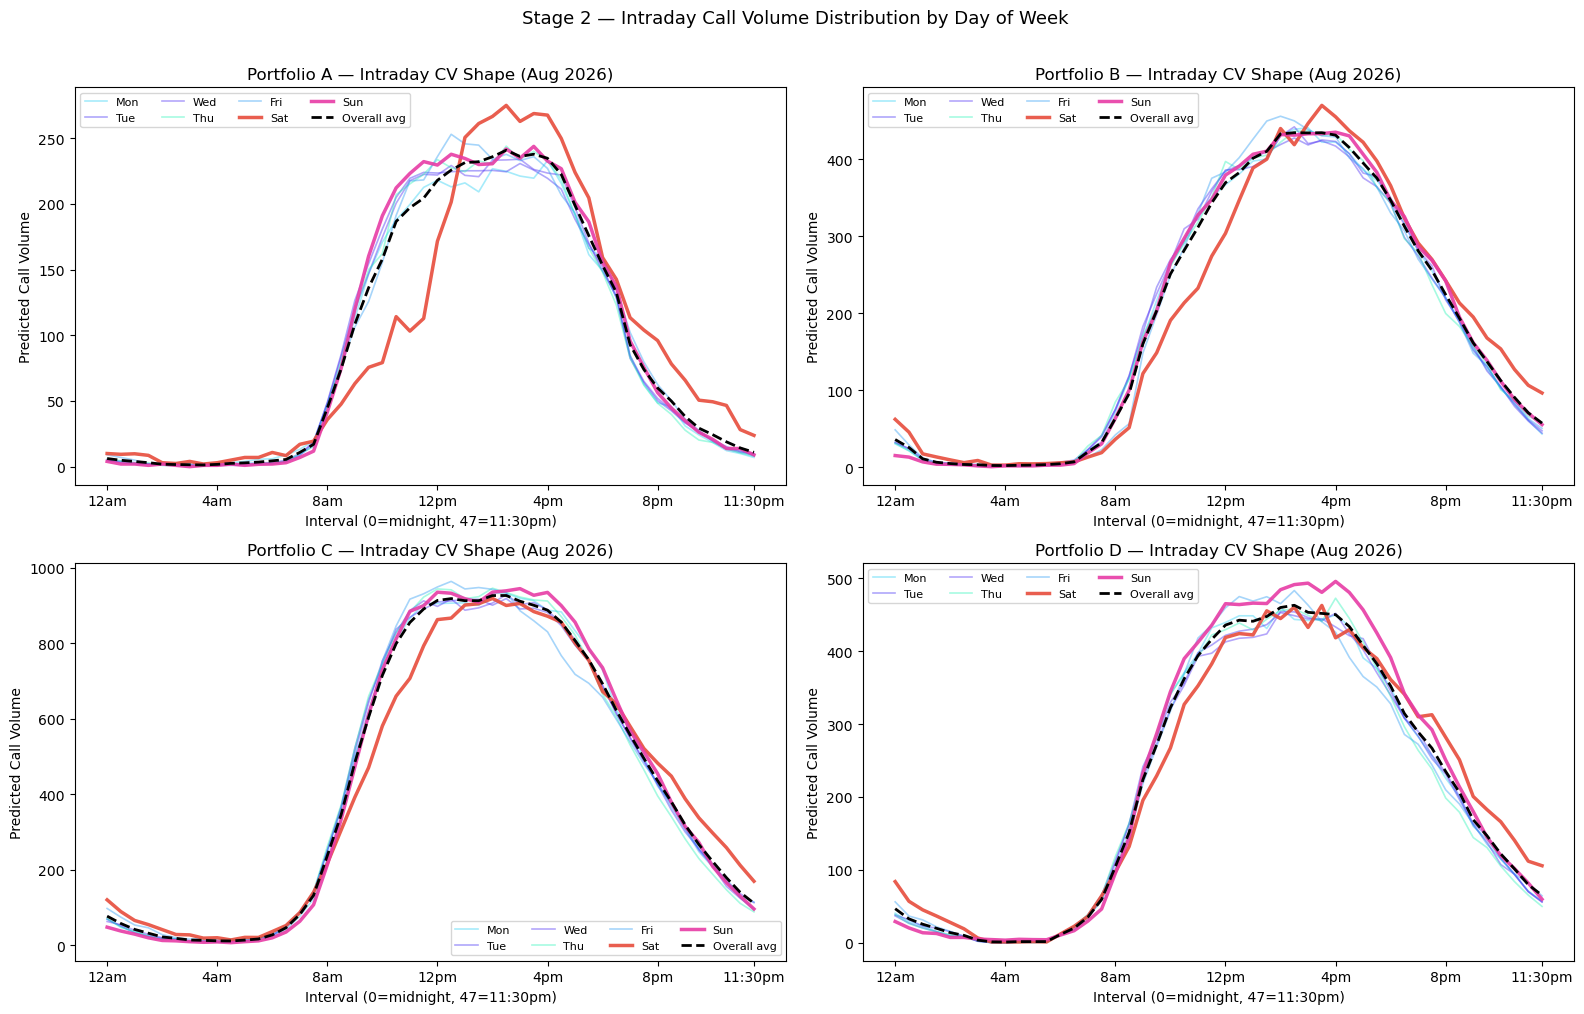


=== Sample output (Portfolio A, Aug 1) ===
    Interval  Call_Volume     CCT  Abandoned_Calls  Abandoned_Rate
0   00:00:00           10   31.48                2        0.172679
1   00:30:00           10   23.30                1        0.141459
2   01:00:00           10   19.95                1        0.073517
3   01:30:00            9   19.69                0        0.035085
4   02:00:00            3    2.67                0        0.000000
5   02:30:00            3    5.92                0        0.000000
6   03:00:00            4    6.45                0        0.000000
7   03:30:00            2    6.00                0        0.000000
8   04:00:00            3    6.72                0        0.000000
9   04:30:00            5    8.15                0        0.000000
10  05:00:00            7   11.00                0        0.000000
11  05:30:00            7   14.15                0        0.000000
12  06:00:00           11   17.69                0        0.000000
13  06:30:00      

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 2 — Intraday Profile Distribution
# ══════════════════════════════════════════════════════════════════════════════

def build_intraday_profiles(cleaned_dict):
    """
    For each (Portfolio, DayOfWeek, IntervalIdx), compute what fraction
    of the daily total each interval represents.
    Returns a profile dataframe used to distribute daily predictions.
    """
    profiles = []

    for name, df in cleaned_dict.items():
        # Daily totals per day (to compute fractions against)
        daily_cv  = df.groupby(['Date'])['Call Volume'].transform('sum')
        daily_abd = df.groupby(['Date'])['Abandoned Calls'].transform('sum')

        df = df.copy()
        df['cv_share']  = df['Call Volume']  / daily_cv.clip(1)
        df['abd_share'] = df['Abandoned Calls'] / daily_abd.clip(1)

        # CCT: weighted contribution = (CCT * CV) / daily_total_cv
        # We'll store weighted CCT numerator share, reconstruct later
        df['cct_weight_share'] = (df['CCT'] * df['Call Volume']) / daily_cv.clip(1)

        # Average the shares by (DayOfWeek, Interval)
        profile = (
            df.groupby(['DayOfWeek_N', 'IntervalIdx', 'Interval'])
              .agg(
                  cv_share         = ('cv_share',         'mean'),
                  abd_share        = ('abd_share',         'mean'),
                  cct_weight_share = ('cct_weight_share',  'mean'),
                  cv_mean          = ('Call Volume',        'mean'),
              )
              .reset_index()
        )

        # Normalize cv_share so each day_of_week sums to exactly 1.0
        dow_totals = profile.groupby('DayOfWeek_N')['cv_share'].transform('sum')
        profile['cv_share_norm']  = profile['cv_share']  / dow_totals.clip(1e-9)

        dow_abd_totals = profile.groupby('DayOfWeek_N')['abd_share'].transform('sum')
        profile['abd_share_norm'] = profile['abd_share'] / dow_abd_totals.clip(1e-9)

        profile['Portfolio'] = name
        profiles.append(profile)

    return pd.concat(profiles, ignore_index=True)


def apply_intraday_profiles(august_preds, profiles_df):
    """
    Distribute each day's predicted daily total across 48 intervals
    using the intraday profile for that portfolio × day-of-week.
    """
    all_intervals = []

    for _, day_row in august_preds.iterrows():
        portfolio = day_row['Portfolio']
        date      = pd.to_datetime(day_row['Date'])
        dow       = date.dayofweek
        daily_cv  = day_row['CV']
        daily_cct = day_row['CCT']
        daily_abd = day_row['ABD']

        # Get the profile for this portfolio + day of week
        pf_profile = profiles_df[
            (profiles_df['Portfolio']   == portfolio) &
            (profiles_df['DayOfWeek_N'] == dow)
        ].sort_values('IntervalIdx').copy()

        if pf_profile.empty:
            # Fallback: flat distribution if no profile exists
            pf_profile = profiles_df[
                profiles_df['Portfolio'] == portfolio
            ].groupby('IntervalIdx').mean(numeric_only=True).reset_index()
            pf_profile['cv_share_norm']  = 1 / 48
            pf_profile['abd_share_norm'] = 1 / 48

        # ── Distribute CV ─────────────────────────────────────────────────────
        interval_cv = (pf_profile['cv_share_norm'] * daily_cv).clip(0)

        # ── Distribute Abandoned Calls, derive ABD Rate per interval ──────────
        interval_abd_calls = (pf_profile['abd_share_norm'] * 
                              daily_abd * daily_cv).clip(0)
        interval_abd_rate  = (interval_abd_calls / interval_cv.clip(1)).clip(0, 1)

        # ── CCT: use historical interval-level mean shape, scaled to daily mean─
        # Scale so that volume-weighted mean matches predicted daily CCT
        raw_cct     = pf_profile['cct_weight_share'].values
        raw_cv      = pf_profile['cv_mean'].values
        weighted_mean = np.average(raw_cct, weights=raw_cv.clip(1e-9)) if raw_cv.sum() > 0 else 1
        scale_factor  = daily_cct / weighted_mean if weighted_mean > 0 else 1.0
        interval_cct  = (raw_cct * scale_factor).clip(0)

        # ── Build interval rows ───────────────────────────────────────────────
        for idx, (_, interval_row) in enumerate(pf_profile.iterrows()):
            all_intervals.append({
                'Portfolio':       portfolio,
                'Date':            date,
                'Month':           date.strftime('%B'),
                'Day':             date.day,
                'DayOfWeek':       date.strftime('%A'),
                'DayOfWeek_N':     dow,
                'Interval':        interval_row['Interval'],
                'IntervalIdx':     interval_row['IntervalIdx'],
                'Call_Volume':     round(interval_cv.iloc[idx]),
                'CCT':             round(interval_cct[idx], 2),
                'Abandoned_Calls': round(interval_abd_calls.iloc[idx]),
                'Abandoned_Rate':  round(interval_abd_rate.iloc[idx], 6),
            })

    result = pd.DataFrame(all_intervals)

    # Final safety clip — enforce non-negativity contest rule
    result['Call_Volume']     = result['Call_Volume'].clip(0).astype(int)
    result['Abandoned_Calls'] = result['Abandoned_Calls'].clip(0).astype(int)
    result['CCT']             = result['CCT'].clip(0)
    result['Abandoned_Rate']  = result['Abandoned_Rate'].clip(0, 1)

    return result


# ── Run Stage 2 ───────────────────────────────────────────────────────────────
print("Building intraday profiles from historical data...")
profiles_df = build_intraday_profiles(cleaned)
print(f"Profile shape: {profiles_df.shape} "
      f"({profiles_df['Portfolio'].nunique()} portfolios × "
      f"{profiles_df['DayOfWeek_N'].nunique()} days × "
      f"{profiles_df['IntervalIdx'].nunique()} intervals)")

print("\nApplying profiles to August 2026 daily predictions...")
august_intervals = apply_intraday_profiles(august_preds, profiles_df)
print(f"Output shape: {august_intervals.shape}")
print(f"Expected:     {31 * 48 * 4} rows (31 days × 48 intervals × 4 portfolios)")
print(august_intervals.head(10))

# ── Validation: daily totals should match Stage 1 predictions ─────────────────
print("\n=== Validation: Stage 2 daily CV vs Stage 1 predictions ===")
recon = (august_intervals
         .groupby(['Portfolio', 'Date'])['Call_Volume']
         .sum()
         .reset_index()
         .rename(columns={'Call_Volume': 'CV_reconstructed'}))

check = august_preds.merge(recon, on=['Portfolio', 'Date'])
check['diff'] = (check['CV'] - check['CV_reconstructed']).abs()
print(check.groupby('Portfolio')[['CV', 'CV_reconstructed', 'diff']]
      .mean().round(1).to_string())

# ── Plot: intraday shape for each portfolio (avg across August) ───────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
colors_dow = ['#21cdf3','#3621f3','#4421f3','#21f3b4','#2196F3','#e74c3c','#e73ca5']

for i, portfolio in enumerate(['A', 'B', 'C', 'D']):
    pf = august_intervals[august_intervals['Portfolio'] == portfolio]

    # Average intraday curve across all Mondays, all Tuesdays, etc.
    for dow in range(7):
        dow_data = pf[pf['DayOfWeek_N'] == dow].groupby('IntervalIdx')['Call_Volume'].mean()
        if not dow_data.empty:
            axes[i].plot(dow_data.index, dow_data.values,
                         label=day_names[dow],
                         color=colors_dow[dow],
                         alpha=0.4 if dow < 5 else 0.9,
                         linewidth=1.2 if dow < 5 else 2.5)

    # Bold average across all days
    avg = pf.groupby('IntervalIdx')['Call_Volume'].mean()
    axes[i].plot(avg.index, avg.values, color='black',
                 linewidth=2, linestyle='--', label='Overall avg')

    axes[i].set_title(f'Portfolio {portfolio} — Intraday CV Shape (Aug 2026)')
    axes[i].set_xlabel('Interval (0=midnight, 47=11:30pm)')
    axes[i].set_ylabel('Predicted Call Volume')
    axes[i].set_xticks([0, 8, 16, 24, 32, 40, 47])
    axes[i].set_xticklabels(['12am','4am','8am','12pm','4pm','8pm','11:30pm'])
    axes[i].legend(fontsize=8, ncol=4)

plt.suptitle('Stage 2 — Intraday Call Volume Distribution by Day of Week',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n=== Sample output (Portfolio A, Aug 1) ===")
print(august_intervals[
    (august_intervals['Portfolio'] == 'A') &
    (august_intervals['Day'] == 1)
][['Interval','Call_Volume','CCT','Abandoned_Calls','Abandoned_Rate']].to_string())

In [ ]:
august_intervals

,Portfolio,Date,Month,Day,DayOfWeek,DayOfWeek_N,Interval,IntervalIdx,Call_Volume,CCT,Abandoned_Calls,Abandoned_Rate
0,A,2026-08-01,August,1,Saturday,5,00:00:00,0,10,31.48,2,0.172679
1,A,2026-08-01,August,1,Saturday,5,00:30:00,1,10,23.30,1,0.141459
2,A,2026-08-01,August,1,Saturday,5,01:00:00,2,10,19.95,1,0.073517
3,A,2026-08-01,August,1,Saturday,5,01:30:00,3,9,19.69,0,0.035085
4,A,2026-08-01,August,1,Saturday,5,02:00:00,4,3,2.67,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
5947,D,2026-08-31,August,31,Monday,0,21:30:00,43,146,128.38,2,0.011485
5948,D,2026-08-31,August,31,Monday,0,22:00:00,44,118,105.76,1,0.004861
5949,D,2026-08-31,August,31,Monday,0,22:30:00,45,96,82.41,1,0.013165
5950,D,2026-08-31,August,31,Monday,0,23:00:00,46,73,63.24,0,0.004383


In [ ]:
# ── Cell: Export to template ──────────────────────────────────────────────────
import pandas as pd
import numpy as np

def fill_template(august_intervals, template_path, output_path):
    template = pd.read_csv(template_path)
    print(f"Template loaded: {template.shape[0]} rows × {template.shape[1]} cols")

    def normalise_interval(s):
        parts = str(s).strip().split(':')
        h = int(parts[0])
        m = int(parts[1])
        return f"{h}:{m:02d}"

    template['_interval_key'] = template['Interval'].apply(normalise_interval)

    pred = august_intervals.copy()
    pred['_interval_key'] = pred['Interval'].apply(normalise_interval)

    if pred['Abandoned_Rate'].max() > 1.5:
        pred['Abandoned_Rate'] = pred['Abandoned_Rate'] / 100
        print("  ℹ️  Abandoned_Rate divided by 100")

    portfolio_col_map = {
        'A': ('Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A'),
        'B': ('Calls_Offered_B', 'Abandoned_Calls_B', 'Abandoned_Rate_B', 'CCT_B'),
        'C': ('Calls_Offered_C', 'Abandoned_Calls_C', 'Abandoned_Rate_C', 'CCT_C'),
        'D': ('Calls_Offered_D', 'Abandoned_Calls_D', 'Abandoned_Rate_D', 'CCT_D'),
    }

    filled = template.copy()

    for portfolio, (col_cv, col_abd, col_arate, col_cct) in portfolio_col_map.items():
        pf_pred = pred[pred['Portfolio'] == portfolio][
            ['Day', '_interval_key', 'Call_Volume', 'Abandoned_Calls', 'Abandoned_Rate', 'CCT']
        ].copy().rename(columns={
            'Call_Volume':     col_cv,
            'Abandoned_Calls': col_abd,
            'Abandoned_Rate':  col_arate,
            'CCT':             col_cct,
        })
        filled = filled.drop(columns=[col_cv, col_abd, col_arate, col_cct], errors='ignore')
        filled = filled.merge(pf_pred, on=['Day', '_interval_key'], how='left')

    for portfolio in 'ABCD':
        col_cv, col_abd, col_arate, col_cct = portfolio_col_map[portfolio]
        filled[col_cv]    = filled[col_cv].clip(lower=0).round(0).astype('Int64')
        filled[col_abd]   = filled[col_abd].clip(lower=0).round(0).astype('Int64')
        filled[col_arate] = filled[col_arate].clip(lower=0, upper=1).round(6)
        filled[col_cct]   = filled[col_cct].clip(lower=0).round(2)

    out_cols = [c for c in template.columns if c != '_interval_key']
    filled = filled[out_cols]
    filled.to_csv(output_path, index=False)
    print(f"\n✅  Saved → {output_path}")
    print(f"   Rows: {len(filled)}  |  Nulls: {filled.drop(columns=['Month','Day','Interval']).isnull().sum().sum()}")

    print("\n=== Daily CV totals (spot check) ===")
    for portfolio in 'ABCD':
        col_cv = portfolio_col_map[portfolio][0]
        daily = filled.groupby('Day')[col_cv].sum()
        print(f"  Portfolio {portfolio}: mean={daily.mean():.0f}  min={daily.min():.0f}  max={daily.max():.0f}")

    return filled

# ── Fix the path — template is in ./data/ based on your file explorer ─────────
output_df = fill_template(
    august_intervals,
    template_path='./data/template_forecast_v00.csv',   # ← updated path
    output_path='./August_2026_Forecast_v00.csv',
)
print(output_df.head(3).to_string())

Template loaded: 1488 rows × 19 cols

✅  Saved → ./August_2026_Forecast_v00.csv
   Rows: 1488  |  Nulls: 0

=== Daily CV totals (spot check) ===
  Portfolio A: mean=4571  min=4299  max=4854
  Portfolio B: mean=9043  min=8642  max=9586
  Portfolio C: mean=20603  min=19496  max=21938
  Portfolio D: mean=10147  min=9551  max=11774
    Month  Day Interval  Calls_Offered_A  Abandoned_Calls_A  Abandoned_Rate_A  CCT_A  Calls_Offered_B  Abandoned_Calls_B  Abandoned_Rate_B  CCT_B  Calls_Offered_C  Abandoned_Calls_C  Abandoned_Rate_C  CCT_C  Calls_Offered_D  Abandoned_Calls_D  Abandoned_Rate_D  CCT_D
0  August    1     0:00               10                  2          0.172679  31.48               64                  8          0.125306  56.19              121                  4          0.030445  53.76               79                  2          0.020808  71.15
1  August    1     0:30               10                  1          0.141459  23.30               47                  5          0.11

In [ ]:
"""
export_to_template.py
─────────────────────
Fills template_forecast_v00.csv with predictions from `august_intervals`.
 
Usage (add this cell at the bottom of your notebook):
    exec(open('export_to_template.py').read())
 
Or import the function:
    from export_to_template import fill_template
    output_df = fill_template(august_intervals, template_path, output_path)
"""
 
import pandas as pd
import numpy as np
 
 
def fill_template(august_intervals: pd.DataFrame,
                  template_path: str = './template_forecast_v00.csv',
                  output_path:   str = './August_2026_Forecast_v00.csv') -> pd.DataFrame:
    """
    Parameters
    ----------
    august_intervals : DataFrame
        Output of apply_intraday_profiles(). Must contain columns:
        Portfolio, Day, Interval, Call_Volume, Abandoned_Calls, Abandoned_Rate, CCT
    template_path : str
        Path to the blank template CSV.
    output_path : str
        Where to write the filled CSV.
 
    Returns
    -------
    filled : DataFrame  — the completed template (also written to output_path)
    """
 
    # ── 1. Load the template (keeps exact row order & interval labels) ────────
    template = pd.read_csv(template_path)
    print(f"Template loaded: {template.shape[0]} rows × {template.shape[1]} cols")
 
    # ── 2. Normalise the Interval column in *both* frames to match exactly ────
    #   Template uses  "0:00", "0:30", "10:00"  (no leading zero on hour)
    #   august_intervals may have "00:00:00", "00:30:00", "10:00:00" (HH:MM:SS)
    #   → strip seconds, drop leading zero on hour to match template
 
    def normalise_interval(s: str) -> str:
        """'00:30:00' → '0:30'   |   '10:00:00' → '10:00'   |   '0:30' → '0:30' """
        parts = str(s).strip().split(':')
        h = int(parts[0])
        m = int(parts[1])
        return f"{h}:{m:02d}"
 
    template['_interval_key'] = template['Interval'].apply(normalise_interval)
 
    pred = august_intervals.copy()
    pred['_interval_key'] = pred['Interval'].apply(normalise_interval)
 
    # ── 3. Ensure Abandoned_Rate is a decimal (0–1), not percentage ───────────
    #   The pipeline stores it as a decimal; template expects decimal too.
    #   (If yours is already 0–1, this is a no-op; if it's 0–100, divide.)
    if pred['Abandoned_Rate'].max() > 1.5:          # heuristic: must be % scale
        pred['Abandoned_Rate'] = pred['Abandoned_Rate'] / 100
        print("  ℹ️  Abandoned_Rate divided by 100 (was %-scale, now decimal)")
 
    # ── 4. Build a lookup: (Portfolio, Day, interval_key) → metrics ──────────
    metrics_cols = ['Call_Volume', 'Abandoned_Calls', 'Abandoned_Rate', 'CCT']
    lookup = (
        pred
        .groupby(['Portfolio', 'Day', '_interval_key'])[metrics_cols]
        .first()          # should already be unique; first() is a safety net
    )
 
    # ── 5. Fill the template row-by-row ──────────────────────────────────────
    filled = template.copy()
 
    portfolio_col_map = {
        'A': ('Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A'),
        'B': ('Calls_Offered_B', 'Abandoned_Calls_B', 'Abandoned_Rate_B', 'CCT_B'),
        'C': ('Calls_Offered_C', 'Abandoned_Calls_C', 'Abandoned_Rate_C', 'CCT_C'),
        'D': ('Calls_Offered_D', 'Abandoned_Calls_D', 'Abandoned_Rate_D', 'CCT_D'),
    }
 
    # Vectorised fill: iterate portfolios, merge on (Day, interval_key)
    for portfolio, (col_cv, col_abd, col_arate, col_cct) in portfolio_col_map.items():
        pf_pred = pred[pred['Portfolio'] == portfolio][
            ['Day', '_interval_key', 'Call_Volume', 'Abandoned_Calls', 'Abandoned_Rate', 'CCT']
        ].copy()
 
        pf_pred = pf_pred.rename(columns={
            'Call_Volume':     col_cv,
            'Abandoned_Calls': col_abd,
            'Abandoned_Rate':  col_arate,
            'CCT':             col_cct,
        })
 
        filled = filled.drop(columns=[col_cv, col_abd, col_arate, col_cct], errors='ignore')
        filled = filled.merge(pf_pred, on=['Day', '_interval_key'], how='left')
 
    # ── 6. Final dtype enforcement & non-negativity guarantee ────────────────
    for portfolio in 'ABCD':
        col_cv, col_abd, col_arate, col_cct = portfolio_col_map[portfolio]
 
        filled[col_cv]    = filled[col_cv].clip(lower=0).round(0).astype('Int64')
        filled[col_abd]   = filled[col_abd].clip(lower=0).round(0).astype('Int64')
        filled[col_arate] = filled[col_arate].clip(lower=0, upper=1).round(6)
        filled[col_cct]   = filled[col_cct].clip(lower=0).round(2)
 
    # ── 7. Restore original template column order & drop helper column ────────
    out_cols = list(template.columns)               # exact original order
    filled = filled[out_cols]                       # drop _interval_key automatically
 
    # ── 8. Write output ───────────────────────────────────────────────────────
    filled.to_csv(output_path, index=False)
    print(f"\n✅  Filled template saved → {output_path}")
    print(f"   Rows: {len(filled)}  |  Expected: {31 * 48} = {31*48}")
 
    # ── 9. Quick validation ───────────────────────────────────────────────────
    null_counts = filled.drop(columns=['Month','Day','Interval']).isnull().sum()
    if null_counts.sum() == 0:
        print("   ✅  No nulls — all cells filled.")
    else:
        print(f"\n   ⚠️  Null cells found:\n{null_counts[null_counts > 0]}")
 
    neg_check = {
        col: (filled[col] < 0).sum()
        for col in filled.columns
        if col not in ['Month', 'Day', 'Interval']
    }
    neg_total = sum(neg_check.values())
    if neg_total == 0:
        print("   ✅  No negative values.")
    else:
        print(f"   ⚠️  Negative values found: {neg_check}")
 
    print("\n=== Daily CV totals (spot check) ===")
    for portfolio in 'ABCD':
        col_cv = portfolio_col_map[portfolio][0]
        daily = filled.groupby('Day')[col_cv].sum()
        print(f"  Portfolio {portfolio}: "
              f"mean={daily.mean():.0f}  min={daily.min():.0f}  max={daily.max():.0f}")
 
    return filled
 
 
# ── Run immediately if executed as a script / exec()'d in notebook ────────────
if __name__ == '__main__' or '__file__' not in dir():
    try:
        # august_intervals must already exist in the notebook environment
        output_df = fill_template(
            august_intervals,
            template_path='./template_forecast_v00.csv',
            output_path='./August_2026_Forecast_v00.csv',
        )
        print("\n=== Preview (first 5 rows) ===")
        print(output_df.head().to_string())
    except NameError:
        print("⚠️  `august_intervals` not found in scope.")
        print("   Run Stages 1 & 2 first, then re-run this cell.")
 

FileNotFoundError: [Errno 2] No such file or directory: './template_forecast_v00.csv'

In [ ]:
exec(open('export_to_template.py').read())

FileNotFoundError: [Errno 2] No such file or directory: './template_forecast_v00.csv'